For each of the 3 task variants, we generated 10 sequences using a MILP solver that should get all the conditions right. This notebook verifies that all our conditions are satisifed.

In [91]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, os, glob, json

In [96]:
############# Helper functions #############
# sequences are stored in .js files, we need to read them in as JSON
def read_sequences_js(path):
    with open(path) as f:
        content = f.read()
    content = content.replace('window.SEQUENCE_STRUCTURES = ', '', 1).rstrip().rstrip(';')
    return json.loads(content)

# correct counts of old and new trials
def check_old_new(df, task):
    n = len(df)
    n_old = df.trial_type.value_counts()['old']
    p = n_old / n
    n_old_correct = 156 if task=='task' else 78
    symbol = '✓' if n_old == n_old_correct else 'X'
    print(f'    Old trials: {n_old}/{n} ({p:.0%}) {symbol}')

# correct counts of old trials across conditions
def check_old_conditions(df, task):
    if task == 'task-mixed':
        mem = df.query('trial_type == "old"').groupby(['retrieval_type']).size().values
        symbol = '✓' if (mem == [20,20,19,19]).all() else 'X'
        print(f'    Balanced old trials across conditions: {symbol}')
    else:
        mem = df.query('trial_type == "old"').groupby(['memorability_bin']).size().values
        symbol = '✓' if (mem == mem[0]).all() else 'X'
        print(f'    Balanced old trials across memorability bins: {symbol}')

# values balanced on new & old trials
def check_values(df, task):
    new = df.query('trial_type == "new"').groupby(['memorability_bin','shared_value']).size().values
    symbol = '✓' if (new == new[0]).all() else 'X'
    print(f'    Balanced values on NEW trials across memorability bins: {symbol}')

    if task == 'task':
        old = df.query('trial_type == "old"').groupby(['memorability_bin','old_card_value']).size().values
        symbol = '✓' if (old == old[0]).all() else 'X'
        print(f'    Balanced values on OLD trials across memorability bins: {symbol}')

# delays matched on old trials
def check_delays(df, task):
    if task == 'task':
        # how often does each delay appear, for each memorability bin and value
        delay_df = df.query('trial_type == "old"').groupby(['memorability_bin','old_card_value'])['delay'].value_counts().unstack(fill_value=0)
        # check the counts are equal across all conditions
        symbol = '✓' if (delay_df.nunique() == 1).all() else 'X'
        print(f'    Same delays across memorability bins & old card values: {symbol}')
    
    elif task == 'task-mixed':
        old = df[df["trial_type"] == "old"].copy()

        # the high-memorability item should be more recent exactly 50% of the time on all trials
        old['high_more_recent'] = old['delay_high'] < old['delay_low']
        high_symbol = '✓' if old.high_more_recent.mean() == 0.5 else 'X'
        print(f'    All trials — high-mem item more recent 50% of the time: {high_symbol}')

        # even trials: high-mem and low-mem should have the same delays
        even = old[old["retrieval_type"].isin(["even_1", "even_0"])]
        delay_high_even = even["delay_high"].value_counts().sort_index()
        delay_low_even = even["delay_low"].value_counts().sort_index()
        even_symbol = '✓' if delay_high_even.equals(delay_low_even) else 'X'
        print(f'    Even trials — same delays for high vs low mem: {even_symbol}')

        # even trials: $1 and $0 should have the same delays
        delay_even_v1_high = even[even.retrieval_type == "even_1"]["delay_high"].value_counts().sort_index()
        delay_even_v1_low = even[even.retrieval_type == "even_1"]["delay_low"].value_counts().sort_index()
        delay_even_v0_high = even[even.retrieval_type == "even_0"]["delay_high"].value_counts().sort_index()
        delay_even_v0_low = even[even.retrieval_type == "even_0"]["delay_low"].value_counts().sort_index()
        delay_even = pd.concat([delay_even_v1_high, delay_even_v1_low, delay_even_v0_high, delay_even_v0_low], axis=1).fillna(0)
        # all 4 columns should match each other (high $1, high $0, low $1, low $0)
        even_symbol = '✓' if delay_even.nunique(axis=1).eq(1).all() else 'X'
        print(f'    Even trials — same delays for $1 vs $0, both high/low mem: {even_symbol}')

        # uneven trials: high-mem/low-mem AND $1/$0 should all have the same delays
        uneven = old[old["retrieval_type"].isin(["uneven_h1", "uneven_h0"])].copy()
        uneven["delay_v1"] = np.where(uneven["value_high"] == 1, uneven["delay_high"], uneven["delay_low"])
        uneven["delay_v0"] = np.where(uneven["value_high"] == 0, uneven["delay_high"], uneven["delay_low"])

        all_groups = pd.concat([uneven["delay_high"].value_counts(),uneven["delay_low"].value_counts(),uneven["delay_v1"].value_counts(),uneven["delay_v0"].value_counts()], axis=1).fillna(0)
        uneven_symbol = '✓' if (all_groups.nunique(axis=1) == 1).all() else 'X'
        print(f'    Uneven trials — same delays for high/low mem & $1/$0: {uneven_symbol}')

        # the $1 item should be more recent almost 50% of the time (18/38 or 20/38, can't be 19/38 because of the 50% memorability constraint above - some math problems)
        uneven['delay_v1'] = np.where(uneven['value_high'] == 1, uneven['delay_high'], uneven['delay_low'])
        uneven['delay_v0'] = np.where(uneven['value_high'] == 0, uneven['delay_high'], uneven['delay_low'])
        uneven['v1_more_recent'] = uneven['delay_v1'] < uneven['delay_v0']
        uneven_symbol = '✓' if uneven.v1_more_recent.mean() == 18/38 or uneven.v1_more_recent.mean() == 20/38 else 'X'
        print(f'    Uneven trials — $1 item more recent 50% of the time: {uneven_symbol}')

    elif task == 'task-matched':
        old = df[df["trial_type"] == "old"].copy()

        # $1 should be more recent exactly 50% of the time
        old['v1_more_recent'] = old['delay_value1'] < old['delay_value0']
        symbol = '✓' if old.v1_more_recent.mean() == 0.5 else 'X'
        print(f'    All trials — $1 item more recent 50% of the time: {symbol}')
        
        # first check the delays of the $1 items - matched across memorability?
        delay_v1 = old.groupby("memorability_bin")["delay_value1"].value_counts().unstack(fill_value=0)
        # now check the delays of the $0 items - matched across memorability?
        delay_v0 = old.groupby("memorability_bin")["delay_value0"].value_counts().unstack(fill_value=0)
        # concatenate to check that the delays match across memorability and value
        all_groups = pd.concat([delay_v1, delay_v0])  # 4 rows: high_v1, low_v1, high_v0, low_v0
        symbol = '✓' if (all_groups.nunique() == 1).all() else 'X'
        print(f'    Same delays across memorability bins & old card values: {symbol}')



# random-looking sequences of old/new trials, and memorability bins
def plot_sequences(df, task):
    from matplotlib.patches import Patch

    type_colors = {'new': 'tab:orange', 'old': 'tab:blue'}
    ret_type_colors = {'even_0': 'tab:red', 'even_1': 'tab:purple', 'uneven_h0': 'tab:cyan', 'uneven_h1': 'tab:green'}
    bin_colors = {'high': 'tab:red', 'mid': 'tab:purple', 'low': 'tab:cyan', 'nan': 'white'}
    value_colors = {1: 'tab:red', 0: 'tab:green'}

    def add_legend(ax, colors, **kwargs):
        handles = [Patch(color=c, label=k) for k, c in colors.items()]
        ax.legend(handles=handles, loc='lower right', bbox_to_anchor=(1, 1.05),
                fontsize=6, frameon=False, borderaxespad=0, **kwargs)

    old = df[df.trial_type == 'old']
    new = df[df.trial_type == 'new']

    fig, axes = plt.subplots(4, 1, figsize=(9,3), sharex=True)

    # 1. trial types throughout experiment
    if task == 'task-mixed':
        axes[0].set_title('Trial types', fontsize=10)
        axes[0].set_yticks([0, 1], labels=['old trial type', 'trial type'])
        axes[0].scatter(df['trial_number'], [1] * len(df), c=df['trial_type'].map(type_colors), marker='|', s=300)
        axes[0].scatter(old['trial_number'], [0] * len(old), c=old['retrieval_type'].map(ret_type_colors), marker='|', s=300)
        add_legend(axes[0], {**type_colors, **ret_type_colors}, ncol=3)
    else:
        # just new vs old
        axes[0].set_title('Trial types', fontsize=10)
        axes[0].set_yticks([])
        axes[0].scatter(df['trial_number'], [0] * len(df), c=df['trial_type'].map(type_colors), marker='|', s=300)
        add_legend(axes[0], type_colors)

    # 2. memorabilities throughout experiment
    axes[1].set_title('Memorability bins', fontsize=10)
    axes[1].scatter(df['trial_number'], [0] * len(df), c=df['memorability_bin'].fillna('nan').map(bin_colors), marker='|', s=300)
    axes[1].set_yticks([])
    add_legend(axes[1], bin_colors, ncol=4)

    # 3. Card values
    axes[2].set_title('Values', fontsize=10)
    if task == 'task':
        # new card values, old card values
        axes[2].set_yticks([0,1], labels=['old','new'])
        axes[2].scatter(new['trial_number'], [1] * len(new), c=new['shared_value'].map(value_colors), marker='|', s=300)
        axes[2].scatter(old['trial_number'], [0] * len(old), c=old['old_card_value'].map(value_colors), marker='|', s=300)
        
    elif task == 'task-mixed':
        #  new card values, even old card values
        axes[2].set_yticks([0,1], labels=['old','new'])
        axes[2].scatter(new['trial_number'], [1] * len(new), c=new['shared_value'].map(value_colors), marker='|', s=300)
        axes[2].scatter(old['trial_number'], [0] * len(old), c=old['value_high'].map(value_colors), marker='|', s=300)
        
    elif task == 'task-matched':
        # new card values
        axes[2].set_yticks([])
        axes[2].scatter(new['trial_number'], [0] * len(new), c=new['shared_value'].map(value_colors), marker='|', s=300)
    add_legend(axes[2], value_colors)

    # 4. Delays on old trials
    if task == 'task':
        axes[3].set_title('Delays on old trials', fontsize=10)
        axes[3].plot(old['trial_number'], old['delay'], marker='o', markersize=3, color='tab:blue')
    elif task == 'task-mixed':
        axes[3].set_title('Delays on old trials', fontsize=10)
        axes[3].plot(old['trial_number'], old['delay_high'], marker='o', markersize=3, color='tab:red', label='high')
        axes[3].plot(old['trial_number'], old['delay_low'], marker='o', markersize=3, color='tab:green', label='low')
        axes[3].legend(fontsize=6, frameon=False, loc='upper right')
    elif task == 'task-matched':
        axes[3].set_title('Delays on old trials', fontsize=10)
        axes[3].plot(old['trial_number'], old['delay_value1'], marker='o', markersize=3, color='tab:red', label='$1')
        axes[3].plot(old['trial_number'], old['delay_value0'], marker='o', markersize=3, color='tab:green', label='$0')
        axes[3].legend(fontsize=6, frameon=False, loc='upper right')
    axes[3].set_yticks([7,15])

    for ax in axes:
        ax.set_xticks([])
    plt.tight_layout()
    plt.show()


In [93]:
def run_all(task):
    print(f'\n================== Task: {task} ================== ')
    js_path = f'/Users/chrisiyer/_Current/lab/code/value-associability/episodic-choice-task/{task}/sequences/sequences.js'
    sequences = read_sequences_js(js_path)

    for seq in sequences:
        df = pd.DataFrame(seq['trials']).sort_values('trial_number').reset_index(drop=True)

        check_old_new(df, task)
        check_old_conditions(df, task)
        check_values(df, task)
        check_delays(df, task)
        plot_sequences(df, task)

# Main task


================== Task: task ================== 
    Old trials: 156/312 (50%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Balanced values on OLD trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


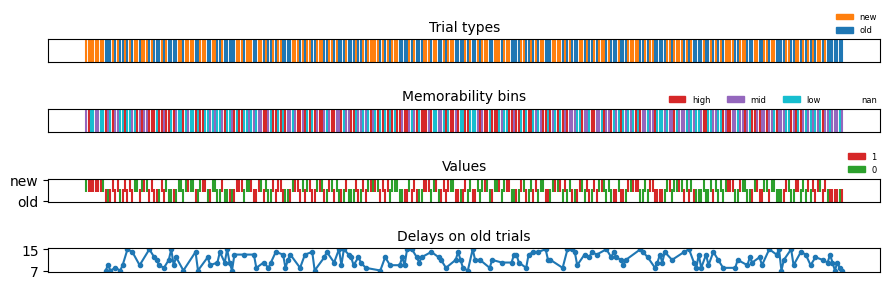

    Old trials: 156/312 (50%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Balanced values on OLD trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


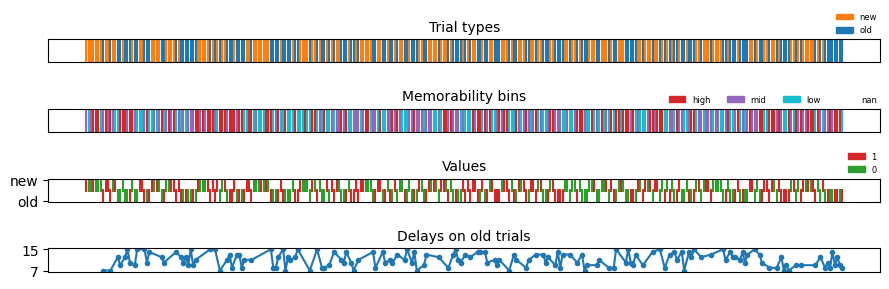

    Old trials: 156/312 (50%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Balanced values on OLD trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


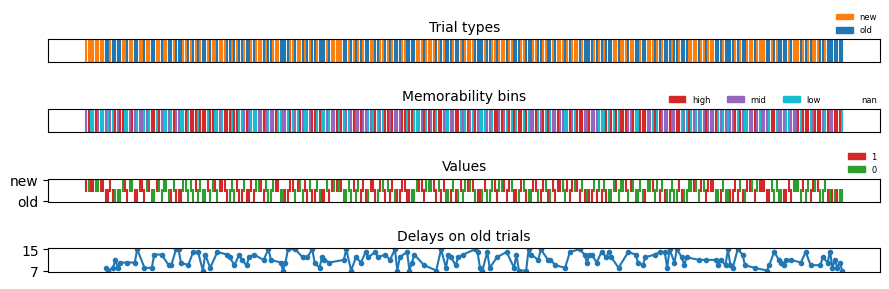

    Old trials: 156/312 (50%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Balanced values on OLD trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


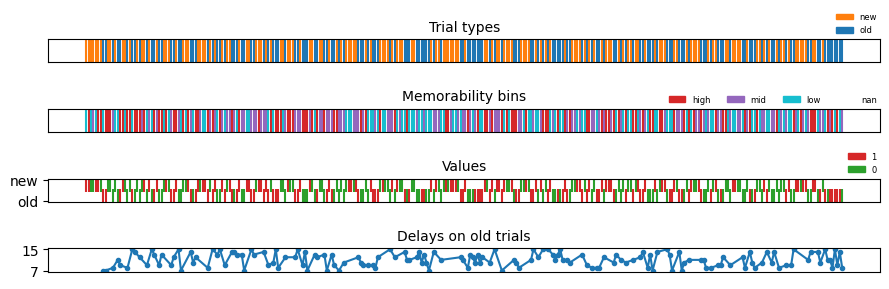

    Old trials: 156/312 (50%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Balanced values on OLD trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


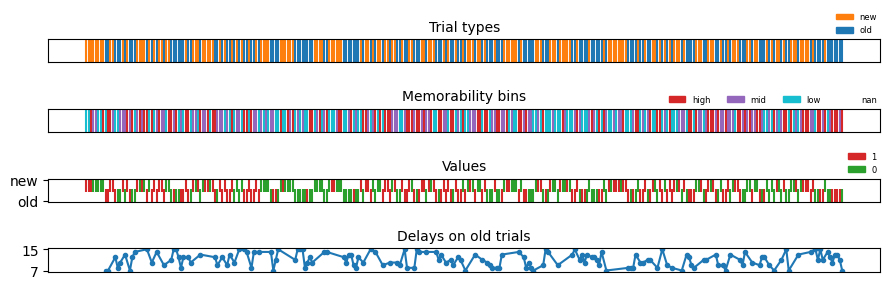

    Old trials: 156/312 (50%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Balanced values on OLD trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


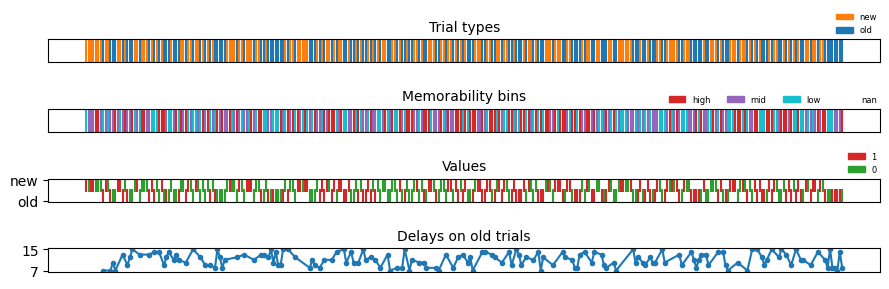

    Old trials: 156/312 (50%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Balanced values on OLD trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


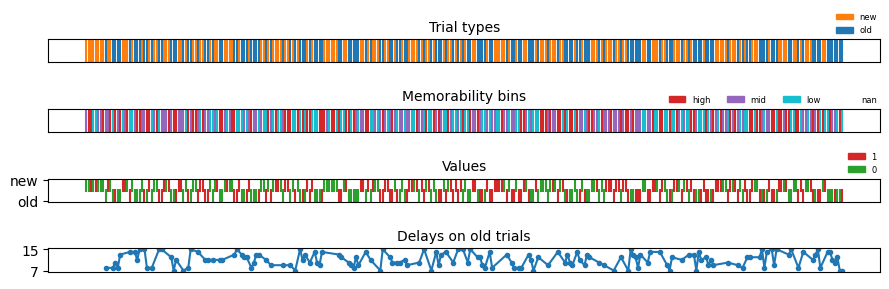

    Old trials: 156/312 (50%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Balanced values on OLD trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


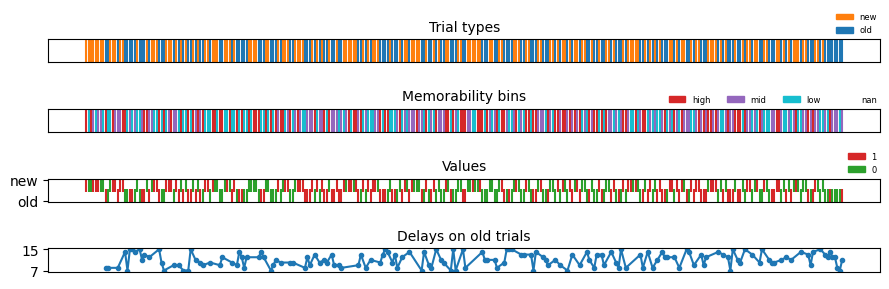

    Old trials: 156/312 (50%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Balanced values on OLD trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


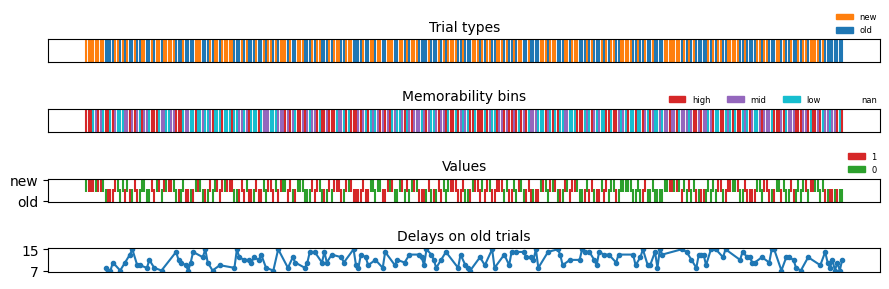

    Old trials: 156/312 (50%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    Balanced values on OLD trials across memorability bins: ✓
    Same delays across memorability bins & old card values: ✓


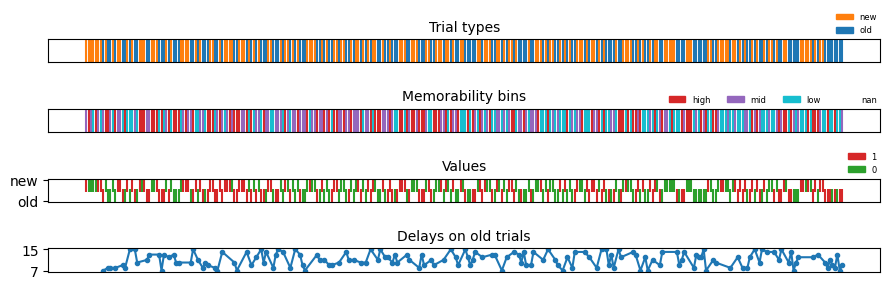

In [94]:
run_all('task')

# Mixed-mem


================== Task: task-mixed ================== 
    Old trials: 78/234 (33%) ✓
    Balanced old trials across conditions: ✓
    Balanced values on NEW trials across memorability bins: ✓
    All trials — high-mem item more recent 50% of the time: ✓
    Even trials — same delays for high vs low mem: ✓
    Even trials — same delays for $1 vs $0, both high/low mem: ✓
    Uneven trials — same delays for high/low mem & $1/$0: ✓
    Uneven trials — $1 item more recent 50% of the time: ✓


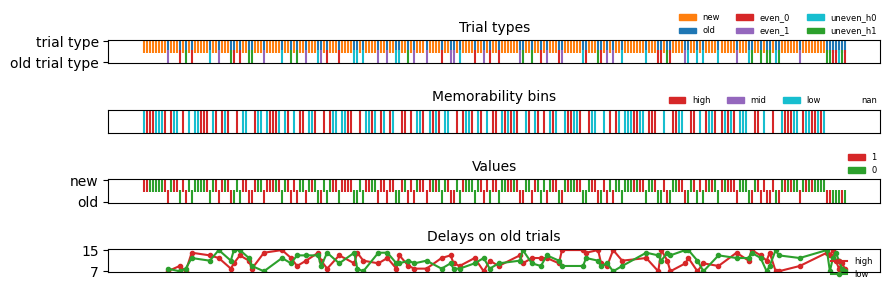

    Old trials: 78/234 (33%) ✓
    Balanced old trials across conditions: ✓
    Balanced values on NEW trials across memorability bins: ✓
    All trials — high-mem item more recent 50% of the time: ✓
    Even trials — same delays for high vs low mem: ✓
    Even trials — same delays for $1 vs $0, both high/low mem: ✓
    Uneven trials — same delays for high/low mem & $1/$0: ✓
    Uneven trials — $1 item more recent 50% of the time: ✓


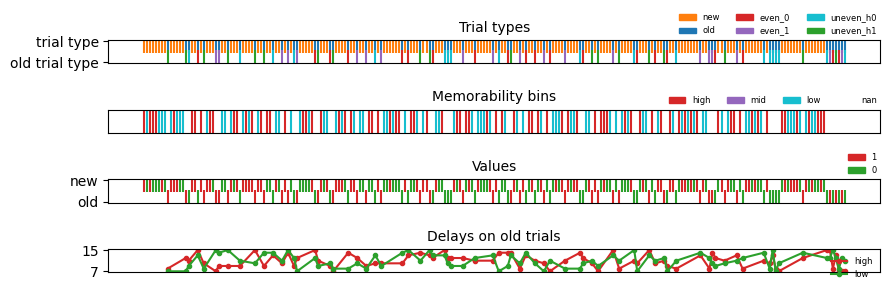

    Old trials: 78/234 (33%) ✓
    Balanced old trials across conditions: ✓
    Balanced values on NEW trials across memorability bins: ✓
    All trials — high-mem item more recent 50% of the time: ✓
    Even trials — same delays for high vs low mem: ✓
    Even trials — same delays for $1 vs $0, both high/low mem: ✓
    Uneven trials — same delays for high/low mem & $1/$0: ✓
    Uneven trials — $1 item more recent 50% of the time: ✓


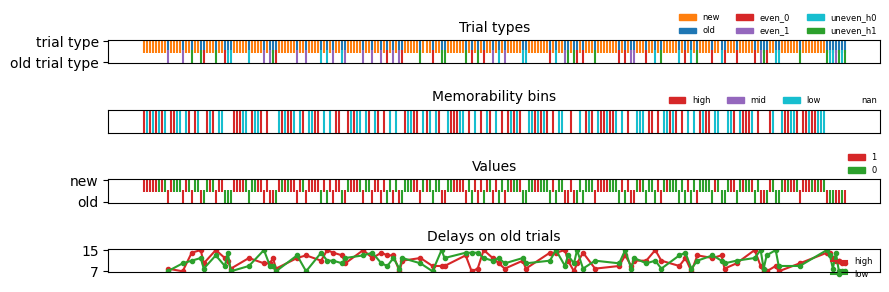

    Old trials: 78/234 (33%) ✓
    Balanced old trials across conditions: ✓
    Balanced values on NEW trials across memorability bins: ✓
    All trials — high-mem item more recent 50% of the time: ✓
    Even trials — same delays for high vs low mem: ✓
    Even trials — same delays for $1 vs $0, both high/low mem: ✓
    Uneven trials — same delays for high/low mem & $1/$0: ✓
    Uneven trials — $1 item more recent 50% of the time: ✓


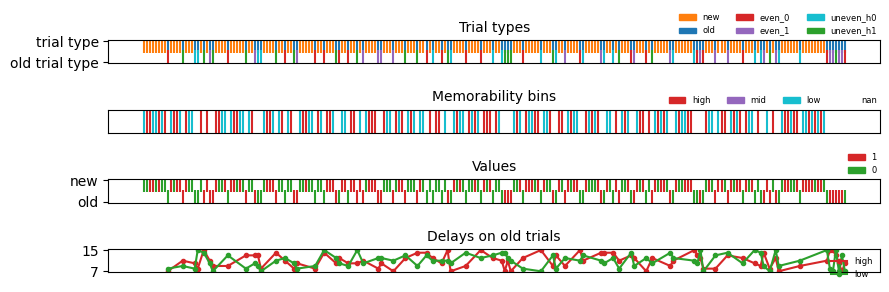

    Old trials: 78/234 (33%) ✓
    Balanced old trials across conditions: ✓
    Balanced values on NEW trials across memorability bins: ✓
    All trials — high-mem item more recent 50% of the time: ✓
    Even trials — same delays for high vs low mem: ✓
    Even trials — same delays for $1 vs $0, both high/low mem: ✓
    Uneven trials — same delays for high/low mem & $1/$0: ✓
    Uneven trials — $1 item more recent 50% of the time: ✓


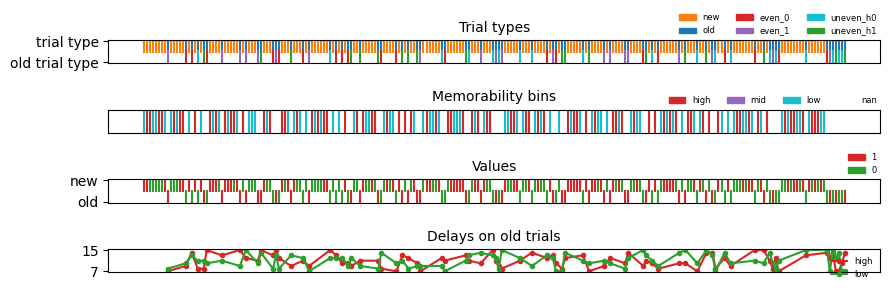

    Old trials: 78/234 (33%) ✓
    Balanced old trials across conditions: ✓
    Balanced values on NEW trials across memorability bins: ✓
    All trials — high-mem item more recent 50% of the time: ✓
    Even trials — same delays for high vs low mem: ✓
    Even trials — same delays for $1 vs $0, both high/low mem: ✓
    Uneven trials — same delays for high/low mem & $1/$0: ✓
    Uneven trials — $1 item more recent 50% of the time: ✓


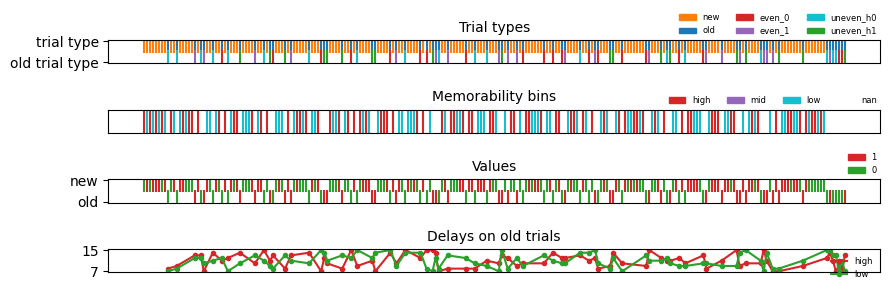

    Old trials: 78/234 (33%) ✓
    Balanced old trials across conditions: ✓
    Balanced values on NEW trials across memorability bins: ✓
    All trials — high-mem item more recent 50% of the time: ✓
    Even trials — same delays for high vs low mem: ✓
    Even trials — same delays for $1 vs $0, both high/low mem: ✓
    Uneven trials — same delays for high/low mem & $1/$0: ✓
    Uneven trials — $1 item more recent 50% of the time: ✓


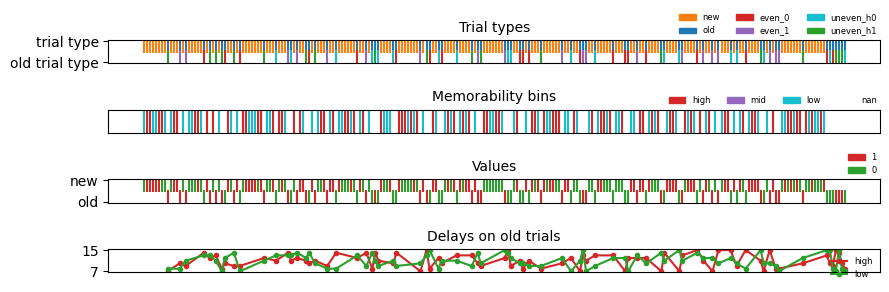

    Old trials: 78/234 (33%) ✓
    Balanced old trials across conditions: ✓
    Balanced values on NEW trials across memorability bins: ✓
    All trials — high-mem item more recent 50% of the time: ✓
    Even trials — same delays for high vs low mem: ✓
    Even trials — same delays for $1 vs $0, both high/low mem: ✓
    Uneven trials — same delays for high/low mem & $1/$0: ✓
    Uneven trials — $1 item more recent 50% of the time: ✓


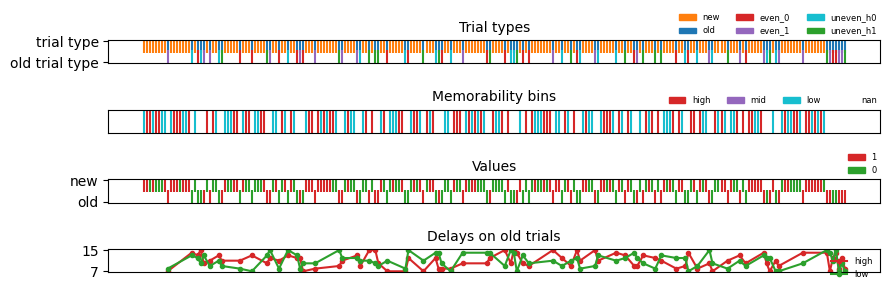

    Old trials: 78/234 (33%) ✓
    Balanced old trials across conditions: ✓
    Balanced values on NEW trials across memorability bins: ✓
    All trials — high-mem item more recent 50% of the time: ✓
    Even trials — same delays for high vs low mem: ✓
    Even trials — same delays for $1 vs $0, both high/low mem: ✓
    Uneven trials — same delays for high/low mem & $1/$0: ✓
    Uneven trials — $1 item more recent 50% of the time: ✓


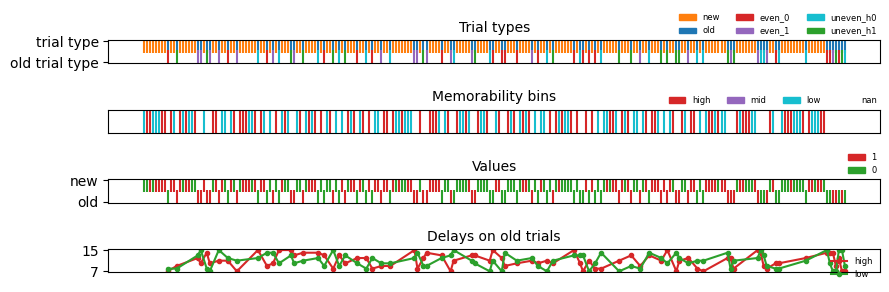

    Old trials: 78/234 (33%) ✓
    Balanced old trials across conditions: ✓
    Balanced values on NEW trials across memorability bins: ✓
    All trials — high-mem item more recent 50% of the time: ✓
    Even trials — same delays for high vs low mem: ✓
    Even trials — same delays for $1 vs $0, both high/low mem: ✓
    Uneven trials — same delays for high/low mem & $1/$0: ✓
    Uneven trials — $1 item more recent 50% of the time: ✓


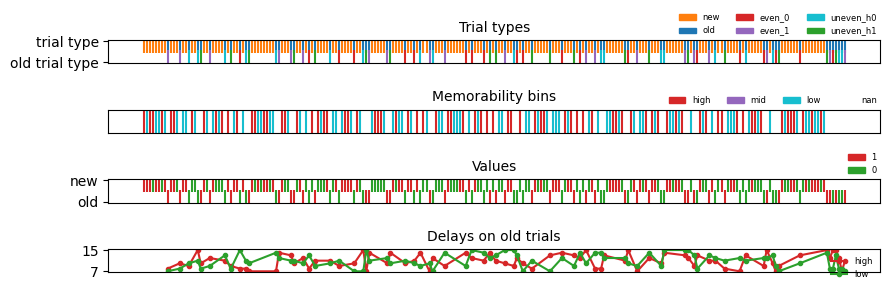

In [97]:
run_all('task-mixed')

# Matched-mem


================== Task: task-matched ================== 
    Old trials: 78/234 (33%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    All trials — $1 item more recent 50% of the time: ✓
    Same delays across memorability bins & old card values: ✓


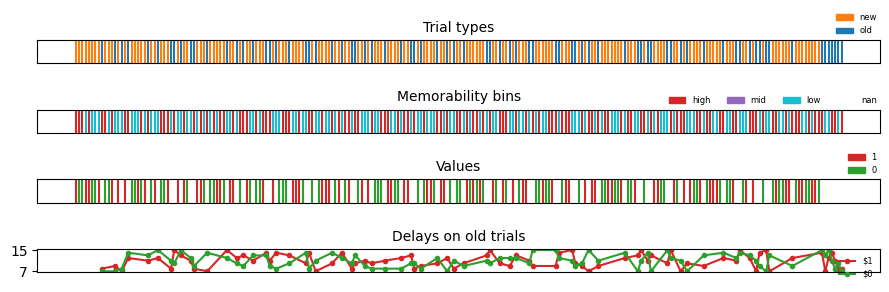

    Old trials: 78/234 (33%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    All trials — $1 item more recent 50% of the time: ✓
    Same delays across memorability bins & old card values: ✓


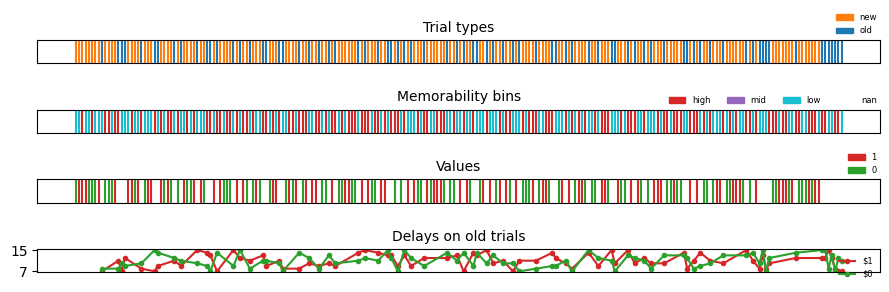

    Old trials: 78/234 (33%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    All trials — $1 item more recent 50% of the time: ✓
    Same delays across memorability bins & old card values: ✓


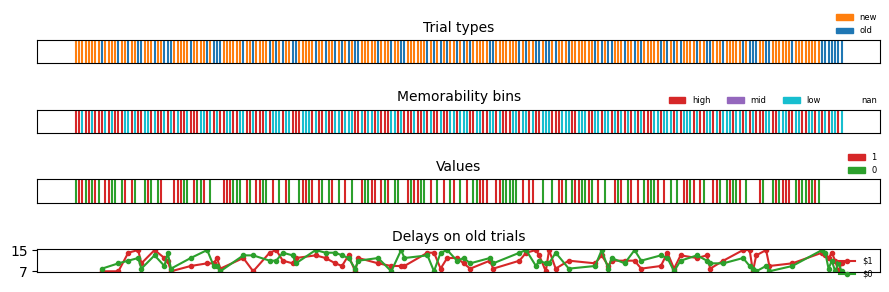

    Old trials: 78/234 (33%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    All trials — $1 item more recent 50% of the time: ✓
    Same delays across memorability bins & old card values: ✓


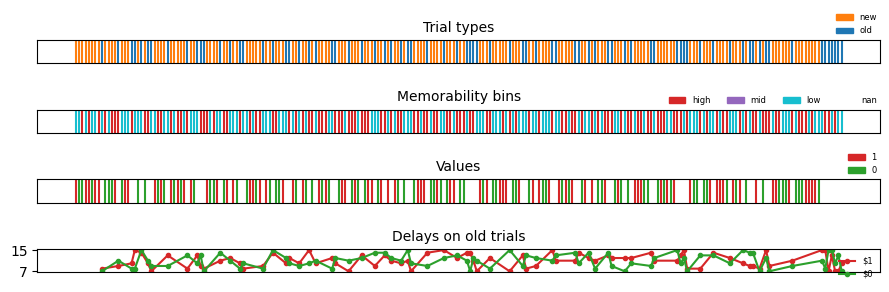

    Old trials: 78/234 (33%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    All trials — $1 item more recent 50% of the time: ✓
    Same delays across memorability bins & old card values: ✓


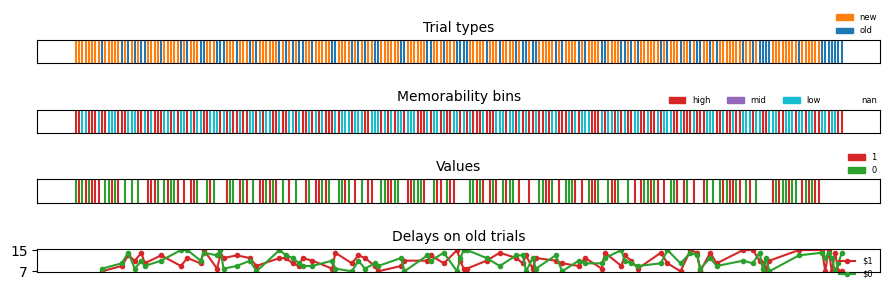

    Old trials: 78/234 (33%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    All trials — $1 item more recent 50% of the time: ✓
    Same delays across memorability bins & old card values: ✓


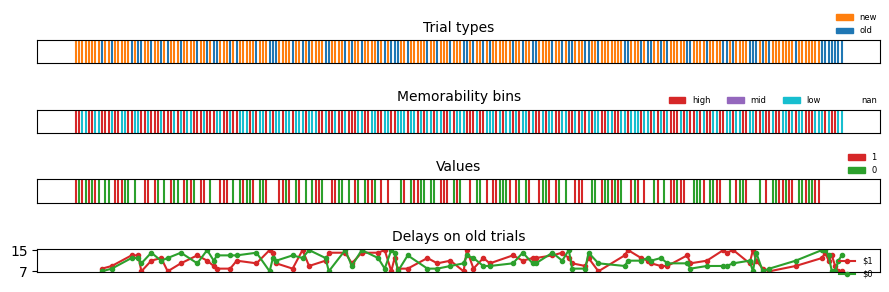

    Old trials: 78/234 (33%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    All trials — $1 item more recent 50% of the time: ✓
    Same delays across memorability bins & old card values: ✓


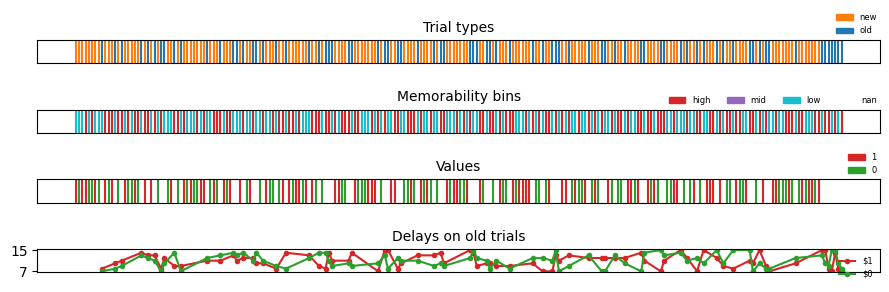

    Old trials: 78/234 (33%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    All trials — $1 item more recent 50% of the time: ✓
    Same delays across memorability bins & old card values: ✓


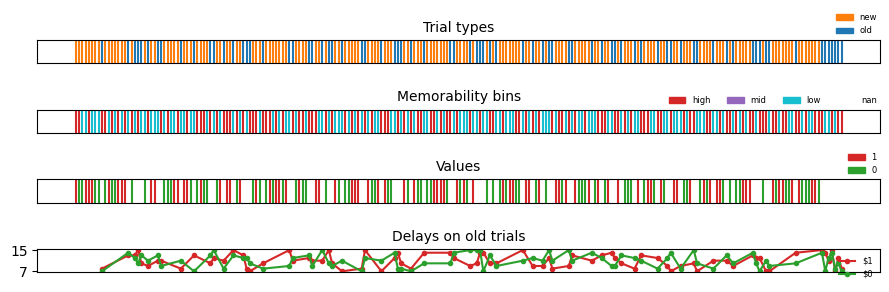

    Old trials: 78/234 (33%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    All trials — $1 item more recent 50% of the time: ✓
    Same delays across memorability bins & old card values: ✓


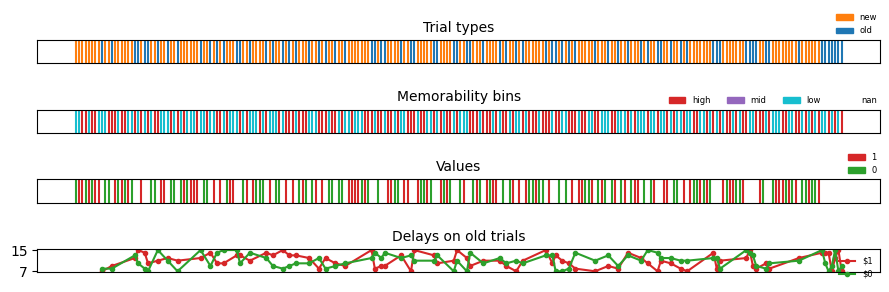

    Old trials: 78/234 (33%) ✓
    Balanced old trials across memorability bins: ✓
    Balanced values on NEW trials across memorability bins: ✓
    All trials — $1 item more recent 50% of the time: ✓
    Same delays across memorability bins & old card values: ✓


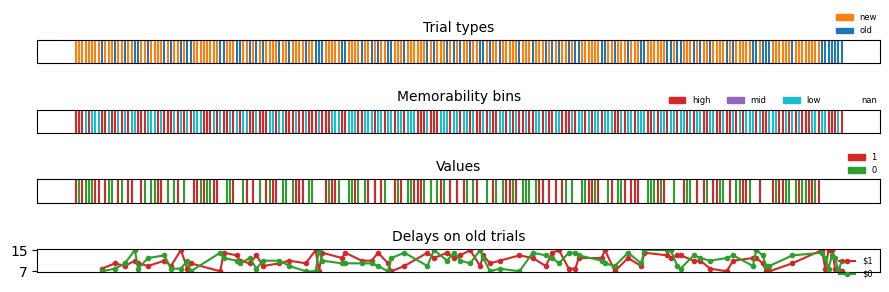

In [98]:
run_all('task-matched')